# 2 Layer Neural network in Pytorch

### What we will do.

1. Generate data
2. Train a Softmax Linear Classifier
3. Train a Neural Network with two layers

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

## Generate data

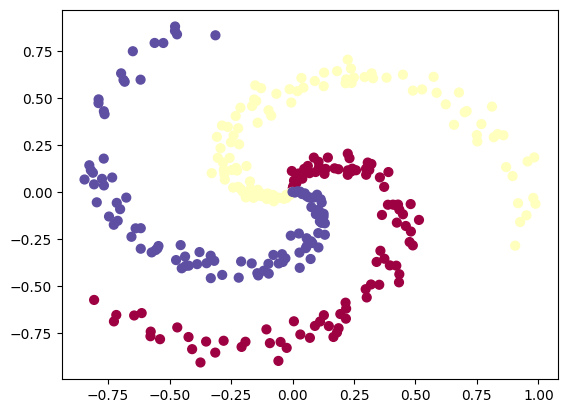

In [ ]:
N = 100 # number of data points per class
D = 2 # data dimensionality
K = 3 # number of classes

X = torch.zeros(N * K, D)                 # data matrix
y = torch.zeros(N * K, dtype=torch.uint8) # class labels

for j in range(K):
    ix = slice(N * j, N * (j + 1))
    r = torch.linspace(0.0, 1, N)
    t = torch.linspace(j * 4, (j + 1) * 4, N) + torch.randn(N) * 0.2  # theta
    X[ix] = torch.stack([r * torch.sin(t), r * torch.cos(t)], dim=1)
    y[ix] = j

plt.scatter(X.numpy()[:, 0], X.numpy()[:, 1], c=y.numpy(), s=40, cmap=plt.cm.Spectral)
plt.show()

## Training a Softmax Linear Classifier

In [ ]:
learning_rate = 1e-1
linear_classifier = nn.Linear(D, K)
optimizer = torch.optim.SGD(linear_classifier.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

for i in range(200):
  pred = linear_classifier(X)
  loss = loss_fn(pred, y)
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()

  if i % 10 == 0:
    print(f"iteration {i}: loss {loss}")


iteration 0: loss 1.2790489196777344
iteration 10: loss 1.1729795932769775
iteration 20: loss 1.1080690622329712
iteration 30: loss 1.0647590160369873
iteration 40: loss 1.0330144166946411
iteration 50: loss 1.0078576803207397
iteration 60: loss 0.986794650554657
iteration 70: loss 0.9685301780700684
iteration 80: loss 0.9523522853851318
iteration 90: loss 0.9378383159637451
iteration 100: loss 0.9247142672538757
iteration 110: loss 0.9127857685089111
iteration 120: loss 0.9019048810005188
iteration 130: loss 0.8919523358345032
iteration 140: loss 0.8828275799751282
iteration 150: loss 0.8744450807571411
iteration 160: loss 0.866729736328125
iteration 170: loss 0.8596158623695374
iteration 180: loss 0.8530458807945251
iteration 190: loss 0.8469683527946472


### Evaluate accuracy

In [25]:
with torch.no_grad():
  scores = linear_classifier(X)
  predicted_class = scores.argmax(dim=1)
  accuracy = (predicted_class == y).float().mean()

print(f'training accuracy: {accuracy:.2f}')


training accuracy: 0.51


### Plot the decision boundary

In [26]:
def plot_boundaries(X, y, predict):
    """Plot decision regions + data points.

    X       : (N, 2) data points to scatter (tensor or array)
    y       : (N,)   true labels, used to color the dots (tensor or array)
    predict : callable mapping (M, 2) grid points -> (M,) predicted class ids
    """
    # matplotlib needs numpy — convert tensors safely (detach in case they need grad)
    if torch.is_tensor(X):
        X = X.detach().cpu().numpy()
    if torch.is_tensor(y):
        y = y.detach().cpu().numpy()

    h = 0.02   # grid resolution
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # classify every point on the grid (the classifier decides *how*)
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(grid)                 # predicted class per grid point
    Z = Z.reshape(xx.shape)

    fig = plt.figure()
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral,
                edgecolors='k', linewidths=0.5)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()


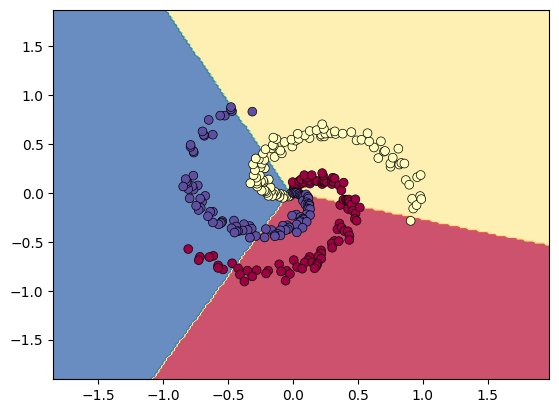

In [27]:
def predict(grid):
    with torch.no_grad():                              # no grad needed for plotting
        grid_t = torch.from_numpy(grid).float()       # numpy grid -> float tensor
        scores = linear_classifier(grid_t)            # -> logits (M, K)
        return scores.argmax(dim=1).cpu().numpy()     # -> class ids as numpy

plot_boundaries(X, y, predict)


## Training a Neural Network with 2 layers

In [30]:
h = 100

class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_relu_stack = nn.Sequential(
      nn.Linear(D, h),
      nn.ReLU(),
      nn.Linear(h, K)
    )

  def forward(self, x):
    return self.linear_relu_stack(x)

model = NeuralNetwork()

In [31]:
print(model)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=3, bias=True)
  )
)


### Training loop

In [34]:
learning_rate = 1e-0
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

for i in range(10000):
  pred = model(X)
  loss = loss_fn(pred, y)

  if i % 1000 == 0:
    print(f"iteration {i}: loss {loss:.6f}")

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()

iteration 0: loss 1.072312
iteration 1000: loss 0.064179
iteration 2000: loss 0.039498
iteration 3000: loss 0.031558
iteration 4000: loss 0.027305
iteration 5000: loss 0.024576
iteration 6000: loss 0.022669
iteration 7000: loss 0.021243
iteration 8000: loss 0.020122
iteration 9000: loss 0.019209


Check accuracy

In [37]:
with torch.no_grad():
  scores = model(X)
  predicted_class = scores.argmax(dim=1)
  accuracy = (predicted_class == y).float().mean()

print(f'training accuracy: {accuracy:.2f}%')

training accuracy: 0.99%


## Plot decision boundaries

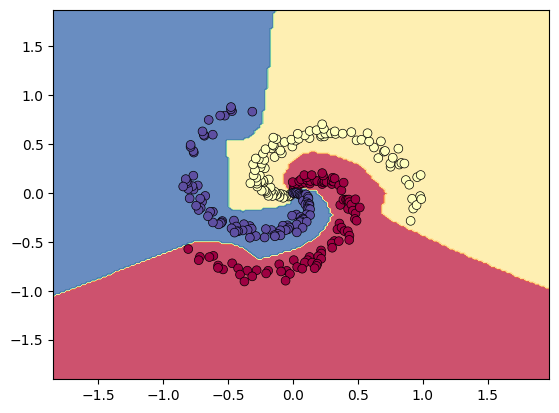

In [38]:
def predict_nn(grid):
    with torch.no_grad():                              # no grad needed for plotting
        grid_t = torch.from_numpy(grid).float()       # numpy grid -> float tensor
        scores = model(grid_t)            # -> logits (M, K)
        return scores.argmax(dim=1).cpu().numpy()     # -> class ids as numpy

plot_boundaries(X, y, predict_nn)